<a href="https://colab.research.google.com/github/Rohans1113/Comparative-Performance-Analysis-of-Sorting-Algorithms-on-Large-Scale-Datasets/blob/main/V4_RM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
pip install graphviz

In [4]:
from graphviz import Digraph

def generate_architecture_diagram():
    # Initialize the directed graph
    dot = Digraph(name='APHSF_Architecture', format='png')

    # Set global graph, node, and edge attributes for a clean, academic look
    dot.attr(rankdir='TB', splines='ortho', nodesep='0.8', ranksep='0.8')
    dot.attr('node', shape='box', style='filled,rounded', fillcolor='#f0f4f8',
             fontname='Arial', fontsize='12', margin='0.2,0.1')
    dot.attr('edge', penwidth='1.2', color='#333333', arrowsize='0.8')

    # Define the primary top-level nodes
    dot.node('Input', 'Input Dataset')
    dot.node('Detector', 'Data Characteristic Detector')
    dot.node('Selector', 'Adaptive Algorithm Selection Engine')

    # Define the Parallel Execution Module as a clustered subgraph
    with dot.subgraph(name='cluster_pem') as pem:
        pem.attr(label='Parallel Execution Module', style='dashed',
                 color='#666666', fontname='Arial', fontsize='12')

        pem.node('W1', 'Worker Thread 1')
        # Use a hidden/transparent node just to represent the ellipsis
        pem.node('Dots', '...', shape='plaintext', style='', fillcolor='none', fontsize='16')
        pem.node('Wp', 'Worker Thread p')

        # Force these nodes to align horizontally in the same rank
        pem.attr(rank='same')

    # Define the bottom nodes
    dot.node('Merge', 'k-Way Merge')
    dot.node('Output', 'Sorted Output')

    # Create the directional flow (Edges)
    dot.edge('Input', 'Detector')
    dot.edge('Detector', 'Selector')

    # Flow splitting into parallel threads
    dot.edge('Selector', 'W1')
    dot.edge('Selector', 'Dots', style='dashed', arrowhead='none')
    dot.edge('Selector', 'Wp')

    # Flow merging from parallel threads
    dot.edge('W1', 'Merge')
    dot.edge('Dots', 'Merge', style='dashed', arrowhead='none')
    dot.edge('Wp', 'Merge')

    # Final output
    dot.edge('Merge', 'Output')

    return dot

if __name__ == '__main__':
    # Generate the diagram
    diagram = generate_architecture_diagram()

    # This will render the file to 'aphsf_architecture.png' and attempt to open it
    diagram.render('aphsf_architecture', view=True, cleanup=True)
    print("Diagram successfully generated as 'aphsf_architecture.png'")

Diagram successfully generated as 'aphsf_architecture.png'


In [6]:
from graphviz import Digraph

def generate_parallel_diagram():
    dot = Digraph(name='Parallel_Execution', format='png')
    dot.attr(rankdir='TB', splines='ortho', nodesep='0.5', ranksep='0.8')
    dot.attr('node', shape='box', style='rounded,filled', fontname='Arial', fontsize='11')
    dot.attr('edge', penwidth='1.2', color='#333333', arrowsize='0.8')

    # Top Level
    dot.node('Input', 'Input Dataset\n(n elements)', fillcolor='#e6f2ff', fontsize='12', penwidth='1.5')

    # Subgraph for Partitions
    with dot.subgraph(name='cluster_partitions') as c:
        c.attr(style='dashed', label='Data Partitioning Phase', color='#888888', fontname='Arial')
        c.node('P1', 'Partition P1\n(~n/p elements)', fillcolor='#ffffff')
        c.node('P2', 'Partition P2\n(~n/p elements)', fillcolor='#ffffff')
        c.node('Pdots', '...', shape='none', style='', fillcolor='none', fontsize='16')
        c.node('Pp', 'Partition Pp\n(~n/p elements)', fillcolor='#ffffff')
        c.attr(rank='same')

    # Subgraph for Worker Threads
    with dot.subgraph(name='cluster_threads') as t:
        t.attr(style='dashed', label='Parallel Sorting Phase', color='#888888', fontname='Arial')
        t.node('T1', 'Worker Thread 1\n(Profile + AHS)', fillcolor='#e6ffe6')
        t.node('T2', 'Worker Thread 2\n(Profile + AHS)', fillcolor='#e6ffe6')
        t.node('Tdots', '...', shape='none', style='', fillcolor='none', fontsize='16')
        t.node('Tp', 'Worker Thread p\n(Profile + AHS)', fillcolor='#e6ffe6')
        t.attr(rank='same')

    # Bottom Levels
    dot.node('Merge', 'k-Way Tournament Merge', fillcolor='#fff0e6', fontsize='12', penwidth='1.5')
    dot.node('Output', 'Sorted Output Dataset', fillcolor='#e6f2ff', fontsize='12', penwidth='1.5')

    # Routing Edges
    dot.edge('Input', 'P1')
    dot.edge('Input', 'P2')
    dot.edge('Input', 'Pp')

    dot.edge('P1', 'T1')
    dot.edge('P2', 'T2')
    dot.edge('Pp', 'Tp')

    dot.edge('T1', 'Merge')
    dot.edge('T2', 'Merge')
    dot.edge('Tp', 'Merge')

    dot.edge('Merge', 'Output')

    return dot

if __name__ == '__main__':
    diagram = generate_parallel_diagram()
    diagram.render('figure2', view=True, cleanup=True)
    print("Successfully generated 'figure2.png'")

Successfully generated 'figure2.png'


In [11]:
from graphviz import Digraph

def generate_parallel_diagram():
    dot = Digraph(name='Parallel_Execution', format='png')
    # compound='true' helps the engine respect cluster boundaries
    dot.attr(rankdir='TB', splines='ortho', nodesep='0.6', ranksep='0.8', compound='true')
    dot.attr('node', shape='box', style='rounded,filled', fontname='Arial', fontsize='11')
    dot.attr('edge', penwidth='1.2', color='#333333', arrowsize='0.8')

    # Top Level
    dot.node('Input', 'Input Dataset\n(n elements)', fillcolor='#e6f2ff', fontsize='12', penwidth='1.5')

    # Subgraph for Partitions
    with dot.subgraph(name='cluster_partitions') as c:
        c.attr(style='dashed', label='Data Partitioning Phase', color='#888888', fontname='Arial', margin='15')

        # TRICK: Use an anonymous nested subgraph to strictly enforce the horizontal row
        with c.subgraph() as s:
            s.attr(rank='same')
            s.node('P1', 'Partition P1\n(~n/p elements)', fillcolor='#ffffff')
            s.node('P2', 'Partition P2\n(~n/p elements)', fillcolor='#ffffff')
            s.node('Pdots', '...', shape='none', style='', fillcolor='none', fontsize='18')
            s.node('Pp', 'Partition Pp\n(~n/p elements)', fillcolor='#ffffff')

            # Invisible horizontal edges lock the left-to-right order
            s.edge('P1', 'P2', style='invis')
            s.edge('P2', 'Pdots', style='invis')
            s.edge('Pdots', 'Pp', style='invis')

    # Subgraph for Worker Threads
    with dot.subgraph(name='cluster_threads') as t:
        t.attr(style='dashed', label='Parallel Sorting Phase', color='#888888', fontname='Arial', margin='15')

        # TRICK: Repeat the anonymous nested subgraph for the second row
        with t.subgraph() as s:
            s.attr(rank='same')
            s.node('T1', 'Worker Thread 1\n(Profile + AHS)', fillcolor='#e6ffe6')
            s.node('T2', 'Worker Thread 2\n(Profile + AHS)', fillcolor='#e6ffe6')
            s.node('Tdots', '...', shape='none', style='', fillcolor='none', fontsize='18')
            s.node('Tp', 'Worker Thread p\n(Profile + AHS)', fillcolor='#e6ffe6')

            s.edge('T1', 'T2', style='invis')
            s.edge('T2', 'Tdots', style='invis')
            s.edge('Tdots', 'Tp', style='invis')

    # Bottom Levels
    dot.node('Merge', 'k-Way Tournament Merge', fillcolor='#fff0e6', fontsize='12', penwidth='1.5')
    dot.node('Output', 'Sorted Output Dataset', fillcolor='#e6f2ff', fontsize='12', penwidth='1.5')

    # Routing Edges (Top to Partitions)
    dot.edge('Input', 'P1')
    dot.edge('Input', 'P2')
    dot.edge('Input', 'Pp')

    # Routing Edges (Partitions to Threads)
    # Weight=100 ensures the engine prioritizes keeping these lines short, straight, and vertical
    dot.edge('P1', 'T1', weight='100')
    dot.edge('P2', 'T2', weight='100')
    dot.edge('Pdots', 'Tdots', style='invis', weight='100')
    dot.edge('Pp', 'Tp', weight='100')

    # Routing Edges (Threads to Merge)
    dot.edge('T1', 'Merge')
    dot.edge('T2', 'Merge')
    dot.edge('Tp', 'Merge')

    # Merge to Output
    dot.edge('Merge', 'Output')

    return dot

if __name__ == '__main__':
    diagram = generate_parallel_diagram()
    diagram.render('figure2_aligned_fixed', view=True, cleanup=True)
    print("Successfully generated 'figure2_aligned_fixed.png'")

Successfully generated 'figure2_aligned_fixed.png'


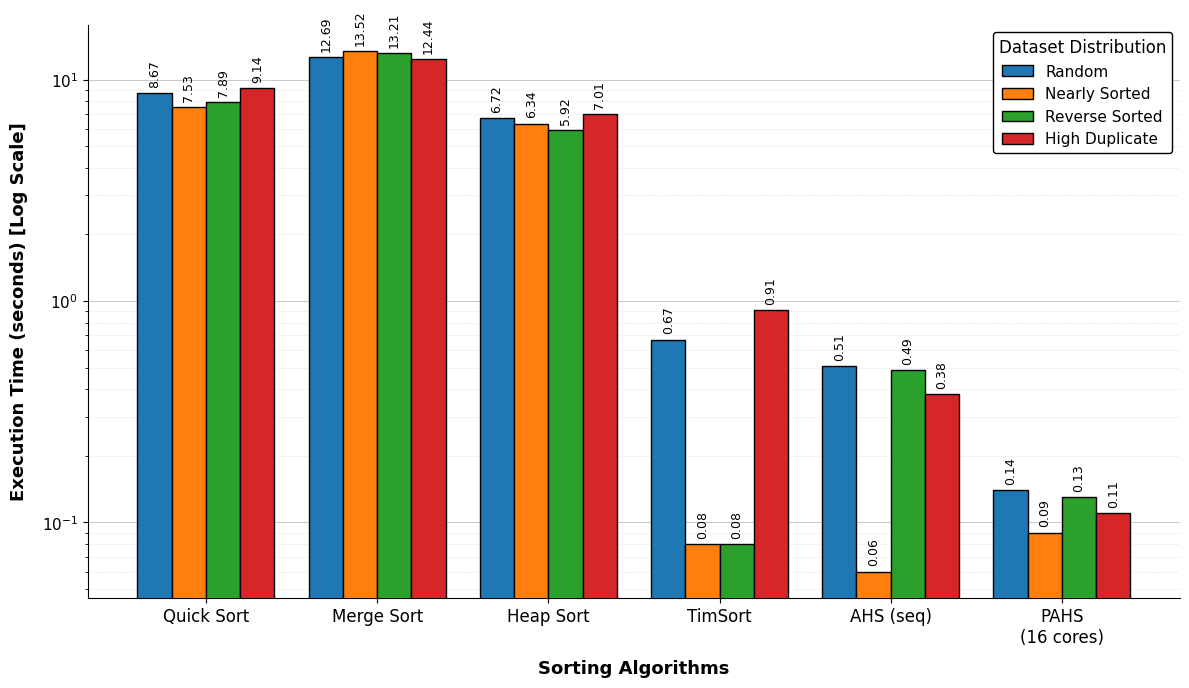

Successfully generated straight-labeled 'figure3.png'


In [17]:
import matplotlib.pyplot as plt
import numpy as np

def generate_straight_label_chart():
    # Data from Table III (n = 10^7)
    # Notice the \n added to the last label so it stacks neatly!
    algorithms = ['Quick Sort', 'Merge Sort', 'Heap Sort', 'TimSort', 'AHS (seq)', 'PAHS\n(16 cores)']
    random = [8.67, 12.69, 6.72, 0.67, 0.51, 0.14]
    nearly_sorted = [7.53, 13.52, 6.34, 0.08, 0.06, 0.09]
    reverse_sorted = [7.89, 13.21, 5.92, 0.08, 0.49, 0.13]
    high_duplicate = [9.14, 12.44, 7.01, 0.91, 0.38, 0.11]

    # Set up the bar locations
    x = np.arange(len(algorithms))
    width = 0.2  # Width of each bar

    # Create the figure
    fig, ax = plt.subplots(figsize=(12, 7))

    # Professional academic color palette
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

    # Plot the grouped bars
    rects1 = ax.bar(x - 1.5*width, random, width, label='Random', color=colors[0], edgecolor='black', linewidth=1, zorder=3)
    rects2 = ax.bar(x - 0.5*width, nearly_sorted, width, label='Nearly Sorted', color=colors[1], edgecolor='black', linewidth=1, zorder=3)
    rects3 = ax.bar(x + 0.5*width, reverse_sorted, width, label='Reverse Sorted', color=colors[2], edgecolor='black', linewidth=1, zorder=3)
    rects4 = ax.bar(x + 1.5*width, high_duplicate, width, label='High Duplicate', color=colors[3], edgecolor='black', linewidth=1, zorder=3)

    # Formatting Y-axis (Log Scale)
    ax.set_yscale('log')
    ax.set_ylabel('Execution Time (seconds) [Log Scale]', fontsize=13, fontweight='bold', labelpad=10)
    ax.tick_params(axis='y', labelsize=11)

    # Formatting X-axis with STRAIGHT labels
    ax.set_xlabel('Sorting Algorithms', fontsize=13, fontweight='bold', labelpad=10)
    ax.set_xticks(x)
    # Rotation removed, text centered
    ax.set_xticklabels(algorithms, fontsize=12, ha='center')

    # Add a subtle, professional grid
    ax.grid(axis='y', which='major', linestyle='-', linewidth=0.7, alpha=0.7, zorder=0)
    ax.grid(axis='y', which='minor', linestyle=':', linewidth=0.5, alpha=0.5, zorder=0)

    # Clean up outer borders (spines) for a modern look
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Legend placement
    ax.legend(title='Dataset Distribution', title_fontsize='12', fontsize='11', loc='upper right', framealpha=1.0, edgecolor='black')

    # Helper function to attach a text label above each bar
    def add_labels(rects):
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height:.2f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 4),
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=9, rotation=90)

    # Apply data labels to all bars
    add_labels(rects1)
    add_labels(rects2)
    add_labels(rects3)
    add_labels(rects4)

    # Clean layout and save
    plt.tight_layout()
    plt.savefig('figure3.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("Successfully generated straight-labeled 'figure3.png'")

if __name__ == '__main__':
    generate_straight_label_chart()

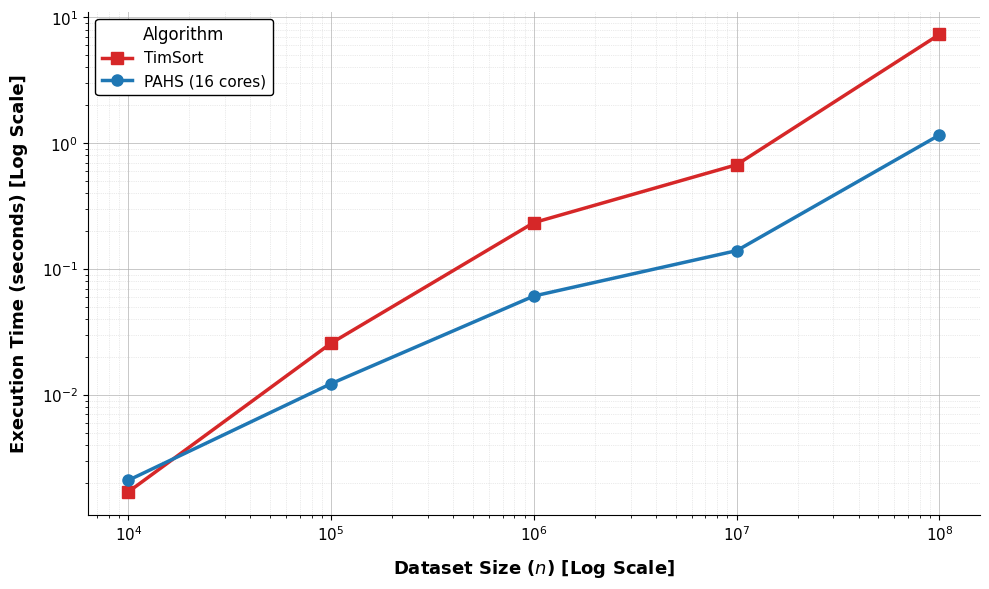

Successfully generated 'figure4.png'


In [18]:
import matplotlib.pyplot as plt

def generate_scaling_line_chart():
    # Data from Table IV
    dataset_sizes = [10**4, 10**5, 10**6, 10**7, 10**8]
    timsort_times = [0.0017, 0.0258, 0.2340, 0.6744, 7.3210]
    pahs_times = [0.0021, 0.0123, 0.0611, 0.1401, 1.1622]

    # Create the figure
    fig, ax = plt.subplots(figsize=(10, 6))

    # Plot the lines with clear markers
    ax.plot(dataset_sizes, timsort_times, marker='s', markersize=8, linewidth=2.5,
            color='#d62728', label='TimSort')

    ax.plot(dataset_sizes, pahs_times, marker='o', markersize=8, linewidth=2.5,
            color='#1f77b4', label='PAHS (16 cores)')

    # Set BOTH axes to logarithmic scale for accurate visual representation of scaling
    ax.set_xscale('log')
    ax.set_yscale('log')

    # Formatting labels
    ax.set_xlabel('Dataset Size ($n$) [Log Scale]', fontsize=13, fontweight='bold', labelpad=10)
    ax.set_ylabel('Execution Time (seconds) [Log Scale]', fontsize=13, fontweight='bold', labelpad=10)
    ax.tick_params(axis='both', labelsize=11)

    # Add a professional grid
    ax.grid(axis='both', which='major', linestyle='-', linewidth=0.7, alpha=0.7)
    ax.grid(axis='both', which='minor', linestyle=':', linewidth=0.5, alpha=0.5)

    # Clean up outer borders
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Legend placement (Top Left is usually best for line graphs that trend upward)
    ax.legend(title='Algorithm', title_fontsize='12', fontsize='11', loc='upper left', framealpha=1.0, edgecolor='black')

    # Clean layout and save
    plt.tight_layout()
    plt.savefig('figure4.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("Successfully generated 'figure4.png'")

if __name__ == '__main__':
    generate_scaling_line_chart()

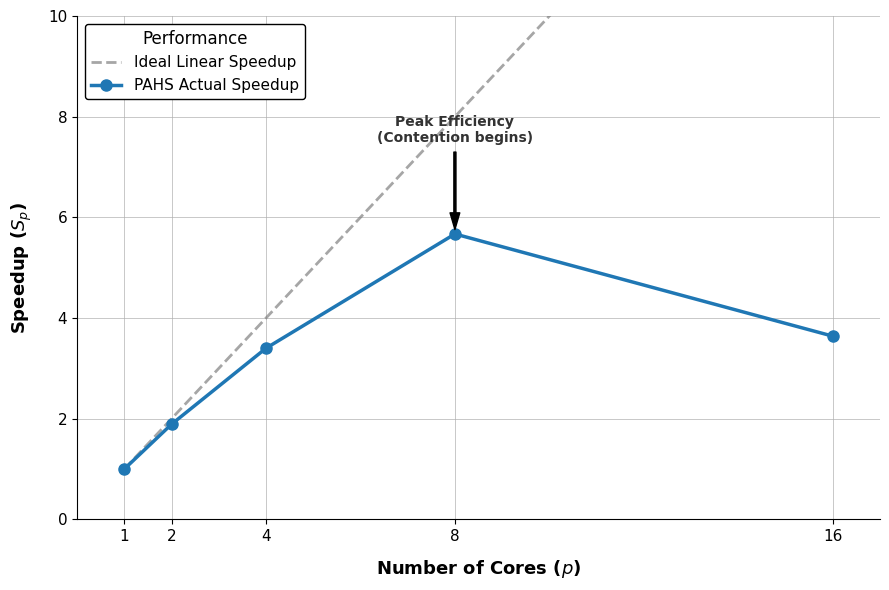

Successfully generated 'figure5.png'


In [19]:
import matplotlib.pyplot as plt

def generate_speedup_chart():
    # Data from Table V
    cores = [1, 2, 4, 8, 16]
    actual_speedup = [1.00, 1.89, 3.40, 5.67, 3.64]
    ideal_speedup = [1, 2, 4, 8, 16] # Theoretical perfect scaling

    # Create the figure
    fig, ax = plt.subplots(figsize=(9, 6))

    # Plot Ideal Speedup (Dashed gray line)
    ax.plot(cores, ideal_speedup, linestyle='--', color='gray', linewidth=2,
            label='Ideal Linear Speedup', alpha=0.7)

    # Plot Actual PAHS Speedup
    ax.plot(cores, actual_speedup, marker='o', markersize=8, linewidth=2.5,
            color='#1f77b4', label='PAHS Actual Speedup')

    # Formatting axes
    ax.set_xlabel('Number of Cores ($p$)', fontsize=13, fontweight='bold', labelpad=10)
    ax.set_ylabel('Speedup ($S_p$)', fontsize=13, fontweight='bold', labelpad=10)

    # Explicitly set X-ticks to only show the tested core counts
    ax.set_xticks(cores)
    ax.tick_params(axis='both', labelsize=11)

    # Set axis limits to give the data some breathing room
    ax.set_xlim(0, 17)
    ax.set_ylim(0, 10)

    # Add a professional grid
    ax.grid(axis='both', which='major', linestyle='-', linewidth=0.7, alpha=0.7)

    # Clean up outer borders
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Legend placement
    ax.legend(title='Performance', title_fontsize='12', fontsize='11', loc='upper left', framealpha=1.0, edgecolor='black')

    # Optional: Annotate the peak performance to highlight it
    ax.annotate('Peak Efficiency\n(Contention begins)',
                xy=(8, 5.67), xytext=(8, 7.5),
                arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=7),
                ha='center', fontsize=10, fontweight='bold', color='#333333')

    # Clean layout and save
    plt.tight_layout()
    plt.savefig('figure5.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("Successfully generated 'figure5.png'")

if __name__ == '__main__':
    generate_speedup_chart()

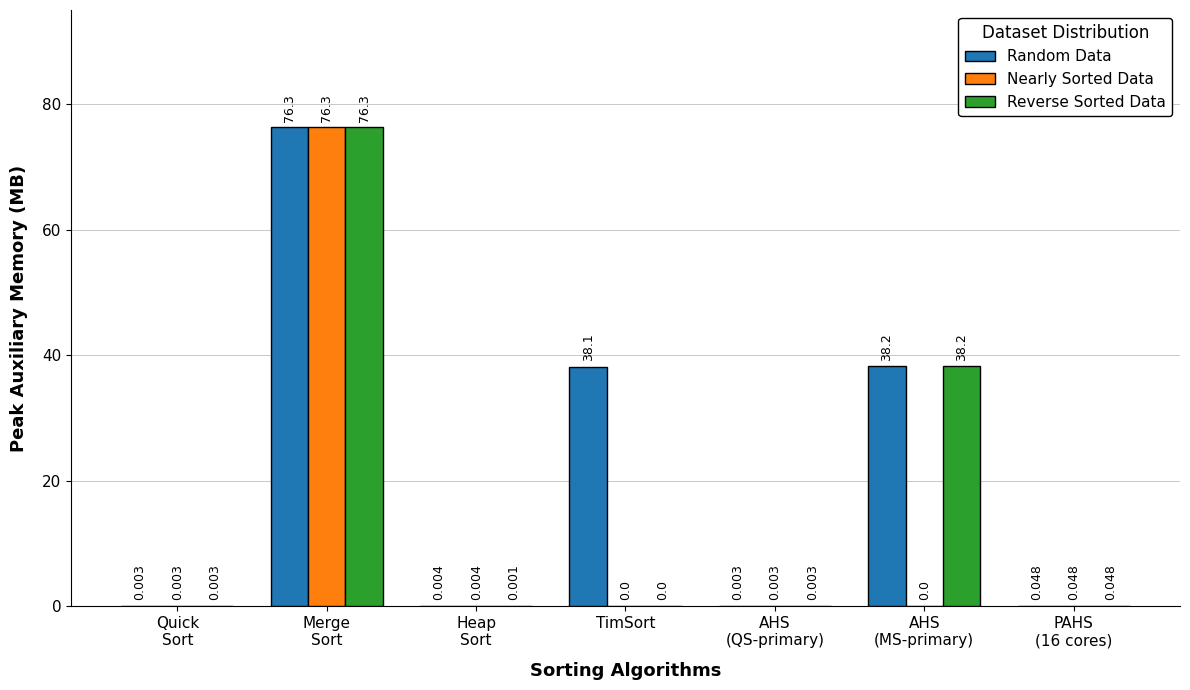

Successfully generated 'figure6.png'


In [21]:
import matplotlib.pyplot as plt
import numpy as np

def generate_memory_chart():
    # Data from Table VI (n = 10^7)
    algorithms = ['Quick\nSort', 'Merge\nSort', 'Heap\nSort', 'TimSort', 'AHS\n(QS-primary)', 'AHS\n(MS-primary)', 'PAHS\n(16 cores)']

    # Memory usage values in MB
    random = [0.003, 76.30, 0.004, 38.15, 0.003, 38.22, 0.048]
    nearly_sorted = [0.003, 76.30, 0.004, 0.000, 0.003, 0.000, 0.048]
    reverse_sorted = [0.003, 76.30, 0.001, 0.000, 0.003, 38.22, 0.048]

    # Set up the bar locations
    x = np.arange(len(algorithms))
    width = 0.25  # Width of each bar

    # Create the figure
    fig, ax = plt.subplots(figsize=(12, 7))

    # Professional academic color palette
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

    # Plot the grouped bars
    rects1 = ax.bar(x - width, random, width, label='Random Data', color=colors[0], edgecolor='black', zorder=3)
    rects2 = ax.bar(x, nearly_sorted, width, label='Nearly Sorted Data', color=colors[1], edgecolor='black', zorder=3)
    rects3 = ax.bar(x + width, reverse_sorted, width, label='Reverse Sorted Data', color=colors[2], edgecolor='black', zorder=3)

    # Formatting axes
    ax.set_ylabel('Peak Auxiliary Memory (MB)', fontsize=13, fontweight='bold', labelpad=10)
    ax.set_xlabel('Sorting Algorithms', fontsize=13, fontweight='bold', labelpad=10)

    # Give the Y-axis some extra headroom for the text labels
    ax.set_ylim(0, 95)

    # Formatting X-ticks to be straight and centered
    ax.set_xticks(x)
    ax.set_xticklabels(algorithms, fontsize=11, ha='center')
    ax.tick_params(axis='y', labelsize=11)

    # Add a subtle, professional grid
    ax.grid(axis='y', which='major', linestyle='-', linewidth=0.7, alpha=0.7, zorder=0)

    # Clean up outer borders
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Legend placement
    ax.legend(title='Dataset Distribution', title_fontsize='12', fontsize='11', loc='upper right', framealpha=1.0, edgecolor='black')

    # Helper function to attach a text label above each bar
    def add_labels(rects):
        for rect in rects:
            height = rect.get_height()
            # If the value is basically zero, format it as "0.0"
            label = "0.0" if height == 0 else f'{height:.3f}' if height < 1 else f'{height:.1f}'
            ax.annotate(label,
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 4),  # 4 points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=9, rotation=90)

    # Apply data labels to all bars
    add_labels(rects1)
    add_labels(rects2)
    add_labels(rects3)

    # Clean layout and save
    plt.tight_layout()
    plt.savefig('figure6.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("Successfully generated 'figure6.png'")

if __name__ == '__main__':
    generate_memory_chart()